<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [2]:
# fijamos todas las semillas para que la corrida sea reproducible
random.seed(42)
np.random.seed(42)
keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()


### Datos

In [3]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [4]:
raw_html = urllib.request.urlopen('https://www.textos.info/dante-alighieri/la-divina-comedia/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [5]:
# tamaño del corpus descargado
print(f'párrafos: {len(article_paragraphs)} | caracteres: {len(article_text)}')


párrafos: 1493 | caracteres: 630720


In [6]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' a la mitad del viaje de nuestra vida me encontré en una selva \nobscura, por haberme apartado del camino recto. ¡ah! cuán penoso me \nsería decir lo salvaje, áspera y espesa que era esta selva, cuyo \nrecuerdo renueva mi pavor, pavor tan amargo, que la muerte no lo es \ntanto. pero antes de hablar del bien que allí encontré, revelaré las \ndemás cosas que he visto. no sé decir fijamente cómo entré allí; tan \nadormecido estaba cuando abandoné el verdadero camino. pero al llegar al\n pie de una cuesta, donde terminaba el valle que me había llenado de \nmiedo el corazón, miré hacia arriba, y vi su cima revestida ya de los \nrayos del planeta que nos guía con seguridad por todos los senderos. \nentonces se calmó algún tanto el miedo que había permanecido en el lago \nde mi corazón durante la noche que pasé con tanta angustia; y del mismo \nmodo que aquel que, saliendo anhelante fuera del piélago, al llegar a la\n playa, se vuelve hacia las ondas peligrosas y las contempla, así mi \nespí

Elegí la Divina Comedia porque es una obra larga de un estilo muy marcado, interesante para ver el estilo en el modelo. El corpus descargado tiene 1493 párrafos y 630720 caracteres.


### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [7]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [8]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [9]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = sorted(set(article_text))  # ordenado: el mapeo char<->índice queda fijo entre sesiones

In [10]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

61

El texto usa 61 caracteres distintos, que es el tamaño del vocabulario con el que trabajo.


In [11]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [12]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [13]:
tokenized_text[:50]

[2,
 23,
 2,
 34,
 23,
 2,
 35,
 31,
 42,
 23,
 26,
 2,
 26,
 27,
 34,
 2,
 44,
 31,
 23,
 32,
 27,
 2,
 26,
 27,
 2,
 36,
 43,
 27,
 41,
 42,
 40,
 23,
 2,
 44,
 31,
 26,
 23,
 2,
 35,
 27,
 2,
 27,
 36,
 25,
 37,
 36,
 42,
 40,
 53,
 2]

### Organizando y estructurando el dataset

In [14]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [15]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [16]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [17]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [18]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

En este punto tenemos en la variable `tokenized_sentences` los versos tokenizados. Vamos a quedarnos con un conjunto de validación que utilizaremos para medir la calidad de la generación de secuencias con la métrica de Perplejidad.

In [19]:
X.shape

(567520, 100)

In [20]:
X[0,:10]

array([ 2, 23,  2, 34, 23,  2, 35, 31, 42, 23])

In [21]:
y[0,:10]

array([23,  2, 34, 23,  2, 35, 31, 42, 23, 26])

In [22]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [23]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, LSTM, GRU, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [24]:
model_rnn = Sequential()

model_rnn.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model_rnn.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model_rnn.add(Dense(vocab_size, activation='softmax'))
model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_rnn.summary()

/Users/elianah/fiuba/CEIA/CEIA-procesamiento-del-lenguaje-natural-i/.venv/lib/python3.11/site-packages/keras/src/layers/core/wrapper.py:25: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 61)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        52,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 61)       │        12,261 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,661 (252.58 KB)

 Trainable params: 64,661 (252.58 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model_lstm = Sequential()

model_lstm.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model_lstm.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model_lstm.add(Dense(vocab_size, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_lstm.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 61)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 200)      │       209,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 61)       │        12,261 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,861 (866.64 KB)

 Trainable params: 221,861 (866.64 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model_gru = Sequential()

model_gru.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model_gru.add(GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model_gru.add(Dense(vocab_size, activation='softmax'))
model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 61)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 200)      │       157,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 61)       │        12,261 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,061 (664.30 KB)

 Trainable params: 170,061 (664.30 KB)

 Non-trainable params: 0 (0.00 B)

Entrené las tres arquitecturas sugeridas en la consigna con la misma configuración para compararlas de forma justa: una capa SimpleRNN, LSTM o GRU de 200 unidades con dropout 0.1, precedida por one-hot y seguida por una densa con softmax, optimizadas con rmsprop. Los tamaños resultan 64661, 221861 y 170061 parámetros.
Espero que LSTM y GRU logren menor perplejidad que la RNN simple porque sus compuertas conservan información a lo largo de más pasos, mientras que en la RNN simple la señal se va perdiendo (desvanecimiento del gradiente).



### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [27]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.history_ppl = history_ppl  # se guarda la lista pasada por argumento para no depender del global history_ppl y poder entrenar varios modelos

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save("my_model.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento

In [28]:
import shutil

# entrenamiento rnn: la perplejidad de validación se guarda en `history_ppl_rnn`
# y el mejor modelo de este fit queda en `model_rnn.keras`
history_ppl_rnn = []
hist_rnn = model_rnn.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl_rnn)], batch_size=256, verbose=0)
shutil.move("my_model.keras", "model_rnn.keras")

E0000 00:00:1790730479.273656 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1790730562.264597 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 5.760089287886748 

Saved new model!


E0000 00:00:1790730682.055749 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 5.116728490031959 

Saved new model!


...

E0000 00:00:1790732659.527786 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 4.515311342733653 



E0000 00:00:1790732775.678228 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 4.510274356423577 



'model_rnn.keras'

In [29]:
# entrenamiento lstm: la perplejidad de validación se guarda en `history_ppl_lstm`
# y el mejor modelo de este fit queda en `model_lstm.keras`
history_ppl_lstm = []
hist_lstm = model_lstm.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl_lstm)], batch_size=256, verbose=0)
shutil.move("my_model.keras", "model_lstm.keras")

E0000 00:00:1790732813.156623 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1790733010.817093 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 7.171174584587352 

Saved new model!


E0000 00:00:1790733262.708662 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 6.232678885300701 

Saved new model!


...

E0000 00:00:1790737598.156147 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 4.206424435674671 

Saved new model!


E0000 00:00:1790737848.160101 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 4.187539518353291 

Saved new model!


'model_lstm.keras'

In [30]:
# entrenamiento gru: la perplejidad de validación se guarda en `history_ppl_gru`
# y el mejor modelo de este fit queda en `model_gru.keras`
history_ppl_gru = []
hist_gru = model_gru.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl_gru)], batch_size=256, verbose=0)
shutil.move("my_model.keras", "model_gru.keras")

E0000 00:00:1790737903.410626 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1790738075.378260 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 5.585149714601817 

Saved new model!


E0000 00:00:1790738295.878432 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 4.671887801826853 

Saved new model!


...

E0000 00:00:1790742019.362939 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 3.8511400033256398 

Saved new model!


E0000 00:00:1790742238.398349 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



 mean perplexity: 3.84608250505784 

Saved new model!


'model_gru.keras'

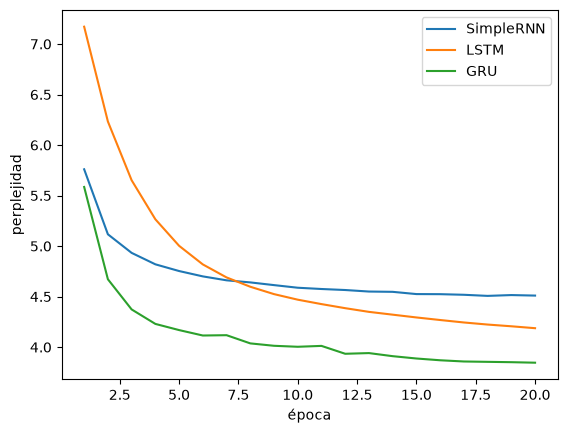

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# perplejidad en validación por época para cada arquitectura
sns.lineplot(x=range(1, len(history_ppl_rnn) + 1), y=history_ppl_rnn, label='SimpleRNN')
sns.lineplot(x=range(1, len(history_ppl_lstm) + 1), y=history_ppl_lstm, label='LSTM')
sns.lineplot(x=range(1, len(history_ppl_gru) + 1), y=history_ppl_gru, label='GRU')
plt.xlabel('época')
plt.ylabel('perplejidad')
plt.legend()
plt.show()


In [32]:
# comparamos por perplejidad mínima en validación (el early stopping guarda el mejor, no el último) y nos quedamos con el mejor para generar
final_ppl = {
    'SimpleRNN': min(history_ppl_rnn),
    'LSTM': min(history_ppl_lstm),
    'GRU': min(history_ppl_gru),
}
for name, ppl in final_ppl.items():
    print(f'{name}: {ppl:.4f}')
best = min(final_ppl, key=final_ppl.get)
print('mejor modelo:', best)
files = {'SimpleRNN': 'model_rnn.keras', 'LSTM': 'model_lstm.keras', 'GRU': 'model_gru.keras'}
model = keras.models.load_model(files[best])


SimpleRNN: 4.5073
LSTM: 4.1875
GRU: 3.8461
mejor modelo: GRU


Entrené 20 épocas con batch 256 guiándome por la perplejidad en validación, con early stopping de patience 5 que en ningún caso llegó a cortar. Los mínimos fueron 4.51 para SimpleRNN, 4.19 para LSTM y 3.85 para GRU, así que me quedé con GRU para generar.
GRU baja más rápido y llega más bajo con menos parámetros que LSTM (170061 contra 221861), mientras que la RNN simple mejora hasta el final pero no las alcanza.



### Predicción del próximo caracter

In [ ]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [33]:
import gradio as gr

def model_response(human_text):

    # Encodeamos
    encoded = [char2idx[ch] for ch in human_text.lower() ]
    # Si tienen distinto largo
    encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

    # Predicción softmax
    y_hat = np.argmax(model.predict(encoded)[0,-1,:])


    # Debemos buscar en el vocabulario el caracter
    # que corresopnde al indice (y_hat) predicho por le modelo
    out_word = ''
    out_word = idx2char[y_hat]

    # Agrego la palabra a la frase predicha
    return human_text + out_word

iface = gr.Interface(
    fn=model_response,
    inputs=["textbox"],
    outputs="text")

# iface.launch(debug=True)

### Generación de secuencias

In [34]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [35]:
seeds = ['a la mitad del viaje', 'maestro, dime', 'en medio del camino']

for input_text in seeds:
    print('seed:', input_text)
    print(generate_seq(model, input_text, max_length=max_context_size, n_words=30))
    print()


seed: a la mitad del viaje


E0000 00:00:1790742290.101747 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


a la mitad del viaje, y 
estaba estaba en el cielo

seed: maestro, dime


maestro, dime quién es 
contemplación de la

seed: en medio del camino


en medio del camino de la 
cabeza de la cabeza de



Probé greedy con tres semillas (`a la mitad del viaje`, `maestro, dime` y `en medio del camino`) generando 30 caracteres. Se nota el límite de la estrategia: como siempre elige el caracter más probable sin mirar adelante, cae en repeticiones (`estaba estaba`, `cabeza de la cabeza de`).
Aun así aparecen palabras del registro del corpus (`cielo`, `contemplación`, `quién`), lo que muestra que el modelo sí capturó vocabulario dantesco.


###  Beam search y muestreo aleatorio

In [36]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [37]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [38]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=20,input="a la mitad del viaje")

E0000 00:00:1790742295.112706 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [39]:
salidas[0]

array([23,  2, 34, 23,  2, 35, 31, 42, 23, 26,  2, 26, 27, 34,  2, 44, 31,
       23, 32, 27,  8,  2, 38, 37, 40,  2, 34, 37,  2, 25, 43, 23, 34,  2,
       35, 27,  2, 26, 31, 32])

In [40]:
# veamos las salidas
decode(salidas[0])

'a la mitad del viaje, por lo cual me dij'

Con la misma semilla probé beam search determinístico con 10 haces y 20 caracteres: `a la mitad del viaje, por lo cual me dij`.
Al explorar varias hipótesis y quedarse con la de mayor probabilidad conjunta evita los loops del greedy y arma una frase globalmente más coherente.


In [41]:
# beam search estocástico con distintas temperaturas (misma seed que el determinístico)
np.random.seed(42)  # el muestreo estocástico queda reproducible
for temp in [0.5, 1.0, 2.0]:
    salidas_sto = beam_search(model, num_beams=5, num_words=20, input="a la mitad del viaje", temp=temp, mode='sto')
    print(f'--- temp={temp} ---')
    for j, s in enumerate(salidas_sto):
        print(f'beam {j}:', decode(s))
    print()


E0000 00:00:1790742300.134032 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


--- temp=0.5 ---
beam 0: a la mitad del viaje, cuando llegamos a 
beam 1: a la mitad del viaje, cuando llegamos a 
beam 2: a la mitad del viaje, cuando llegamos al
beam 3: a la mitad del viaje, cuando llegamos a 
beam 4: a la mitad del viaje, cuando llegamos a 



--- temp=1.0 ---
beam 0: a la mitad del viaje, que puedes permite
beam 1: a la mitad del viaje, que puedes permane
beam 2: a la mitad del viaje, que puedes permane
beam 3: a la mitad del viaje, que puedes permane
beam 4: a la mitad del viaje, que puedes permane



E0000 00:00:1790742305.154339 12974629 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


--- temp=2.0 ---
beam 0: a la mitad del viaje? la vez la 
conteme
beam 1: a la mitad del viaje? la vez la 
contemp
beam 2: a la mitad del viaje? la vez la 
concien
beam 3: a la mitad del viaje? la vez la 
contemp
beam 4: a la mitad del viaje? la vez la 
conteaq



Para el muestreo estocástico fijé `np.random.seed(42)` y probé temperaturas 0.5, 1.0 y 2.0 con 5 haces. Con 0.5 las salidas casi no varían (`cuando llegamos a...`): la distribución se agudiza y se comporta casi como el determinístico.
Con 1.0 aparece variedad (`que puedes permite`, `que puedes permane`). Con 2.0 el modelo diverge (`conteme`, `contemp`, `concien`, `conteaq`): al aplanar la distribución muestrea caracteres raros y arma palabras que no existen. La temperatura 1.0 es el mejor equilibrio entre variedad y sentido.


Elegí la Divina Comedia como corpus propio y entrené sobre ella tres arquitecturas recurrentes (SimpleRNN, LSTM y GRU) con la misma configuración, para poder compararlas usando la métrica de perplejidad en validación. El resultado fue que las tres capas con compuertas le ganaron a la RNN simple, y que entre ellas la GRU fue la mejor: 3.85 contra 4.19 de la LSTM y 4.51 de la SimpleRNN. Dos cosas me parecen relevantes de ese número:
- La primera es la distancia respecto de la referencia del azar: como el modelo trabaja sobre 61 caracteres distintos, una perplejidad de 3.85 significa que en cada paso el modelo le daba peso a unas 4 opciones, no a 61.
- La segunda es que la GRU ganó usando menos parámetros que la LSTM (170061 contra 221861), lo que sugiere que para este corpus y este tamaño de contexto no hacía falta el estado de celda completo.

Después usé el modelo ganador para generar texto con las tres estrategias que pide la consigna:
- El greedy search, que elige el carácter más probable sin mirar adelante, cayó en loops marcados como `estaba estaba` o `cabeza de la cabeza de`, aunque dejó ver vocabulario del corpus.
- El beam search determinístico evitó esos loops y produjo una frase más armada.
- El beam search estocástico con muestreo, en cambio, me permitió ver el tradeoff de la temperatura de forma muy clara: con 0.5 las salidas son casi calcadas entre sí, con 1.0 aparece variedad sin perder el sentido, y con 2.0 el modelo arranca a inventar palabras.  
Ninguno de los tres tiene una mejoría significativa, para este corpus yo usaría 1.0.

Un detalle sobre el entrenamiento que se ve tras mirar los datos: el early stopping con `patience=5` nunca llegó a dispararse en ninguno de los tres modelos, y no porque el margen fuera generoso sino porque la perplejidad siguió bajando hasta la época 20 en todos los casos. Eso me dice que quizá con más épocas el GRU habría seguido mejorando. No opté por seguir entrenando porque el objetivo de la consigna era comparar arquitecturas y no optimizar hiperparámetros, y además el tiempo de entrenamiento ya era considerable en mi PC.
